# Training metrics summary

This notebook loads the training metrics (`.mat` summaries saved by the `TrainingTracker` during training) for each classification task and each model architecture, and puts everything into a single summary table.

For each model, we report the best validation accuracy and loss (at the early stopping epoch), the test accuracy and loss (evaluated on the held-out test set), and the total training time.

In [59]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.io import loadmat

This next section sets up all the parameters: the classification tasks to loop over and the model architectures (net options).

In [60]:
# Classification tasks (each has its own folder in the outputs path)
classif_tasks = ['eventclf', 'ageclf', 'mixed_auditory', 'mixed_visual']

# Model architectures (net options), see meegnet.network for documentation
net_options = ['meegnet', 'eegnet', 'vgg', 'mlp']

# Setting up a seed for reproducibility (will be used for numpy, pandas, torch, and the meegnet library)
seed = 42
n_subjects = 1000
n_channels = 'ALL'

# Setting up paths (relative to the notebooks/ folder)
save_path = os.path.join('..', 'outputs')

### Loading the training metrics

We loop over each classification task: for each task we load the `.mat` summary file of every net option (best validation metrics, test metrics and total training time), followed by the baseline performance (logistic regression on the PSD features of the best single sensor, saved by `train_baseline.py` as `.npy` files). Baselines do not have a validation/test loss nor a training time, so those cells are left empty. This keeps each classification task grouped together in the summary table (5 rows per task: the 4 architectures, then the baseline).

In [61]:
def format_time(seconds):
	"""Formats a duration in seconds as hh:mm."""
	hours, remainder = divmod(seconds, 3600)
	minutes = remainder // 60
	return f'{int(hours):02d}:{int(minutes):02d}'


rows = []
for classif in classif_tasks:
	for net_option in net_options:
		name = f'{classif}_{net_option}_{n_subjects}_{seed}_{n_channels}'
		mat_path = os.path.join(save_path, classif, name + '.mat')
		if not os.path.exists(mat_path):
			print(f'Warning: metrics file not found, skipping: {mat_path}')
			continue
		metrics = loadmat(mat_path)
		rows.append(
			{
				'Classification Task': classif,
				'Model': net_option,
				'Valid Acc': round(100 * float(np.array(metrics['validation_accuracy']).squeeze()), 2),
				'Valid Loss': round(float(np.array(metrics['validation_loss']).squeeze()), 4),
				'Test Acc': round(100 * float(np.array(metrics['test_accuracy']).squeeze()), 2),
				'Test Loss': round(float(np.array(metrics['test_loss']).squeeze()), 4),
				'Epochs': int(np.array(metrics['epoch']).squeeze()),
				'Total Training Time (hh:mm)': format_time(float(np.array(metrics['total_training_time']).squeeze())),
			}
		)
	matches = glob.glob(os.path.join(save_path, classif, f'baseline_performance_{classif}_*.npy'))
	if not matches:
		print(f'Warning: no baseline performance file found for {classif}, skipping baseline row.')
		continue
	baseline = np.load(matches[0], allow_pickle=True).tolist()['best']
	rows.append(
		{
			'Classification Task': classif,
			'Model': 'baseline',
			'Valid Acc': round(100 * float(baseline['validation_accuracy']), 2),
			'Valid Loss': np.nan,
			'Test Acc': round(100 * float(baseline['test_accuracy']), 2),
			'Test Loss': np.nan,
			'Epochs': 0,
			'Total Training Time (hh:mm)': np.nan,
		}
	)

In [62]:
summary = pd.DataFrame(rows)
summary

,Classification Task,Model,Valid Acc,Valid Loss,Test Acc,Test Loss,Epochs,Total Training Time (hh:mm)
0,eventclf,meegnet,94.47,0.1452,95.10,0.1276,30,00:41
1,eventclf,eegnet,94.21,0.1509,95.09,0.1333,538,10:14
2,eventclf,vgg,93.41,0.1613,94.43,0.1346,23,01:09
3,eventclf,mlp,93.18,0.1707,94.12,0.1457,215,03:11
4,eventclf,baseline,64.56,NaN,63.97,NaN,0,NaN
5,ageclf,meegnet,30.41,1.6498,31.34,1.6429,54,01:39
6,ageclf,eegnet,26.16,1.7509,25.78,1.7858,259,11:35
7,ageclf,vgg,24.28,1.8159,24.89,1.8682,14,01:58
8,ageclf,mlp,24.23,1.8367,24.04,1.8431,450,11:20
9,ageclf,baseline,25.62,NaN,21.37,NaN,0,NaN


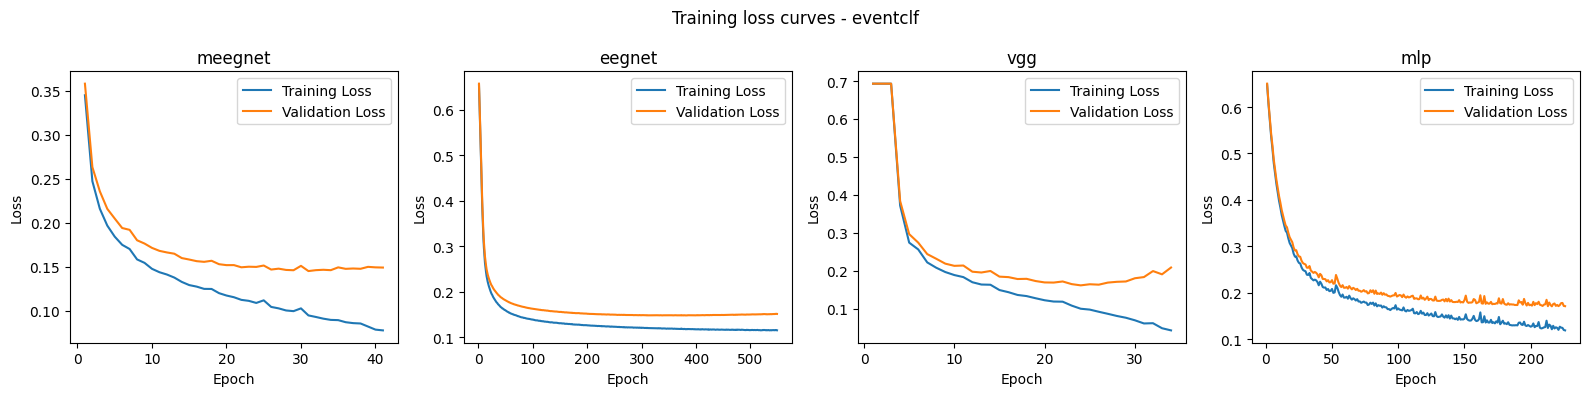

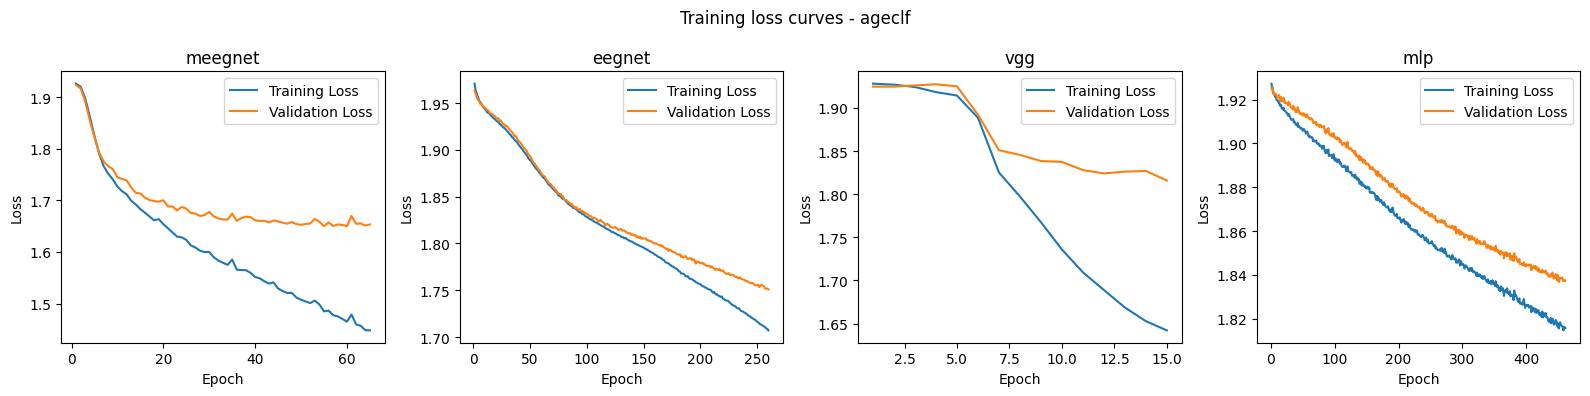

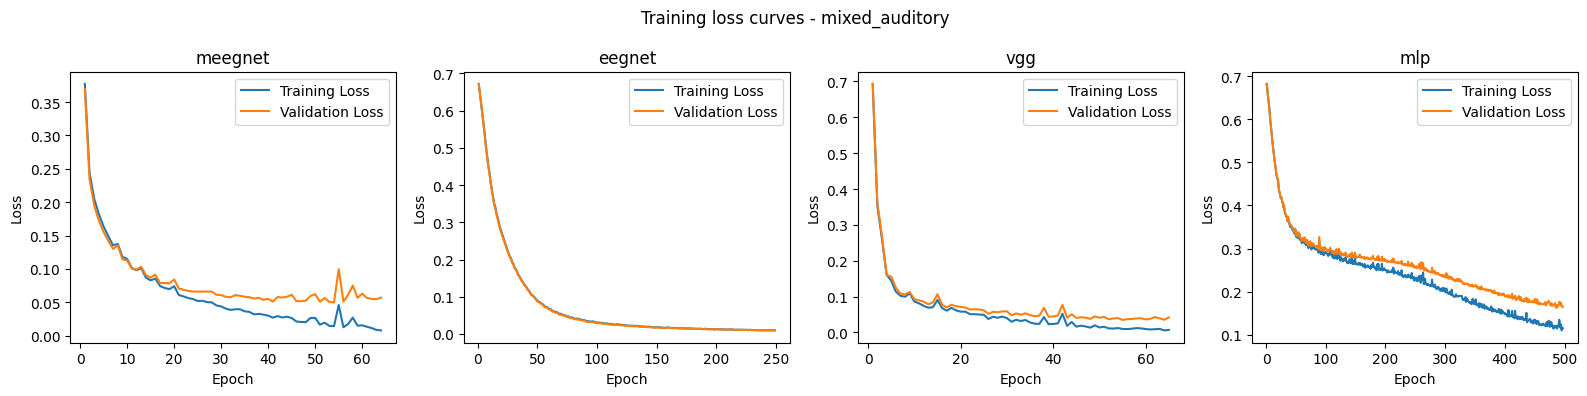

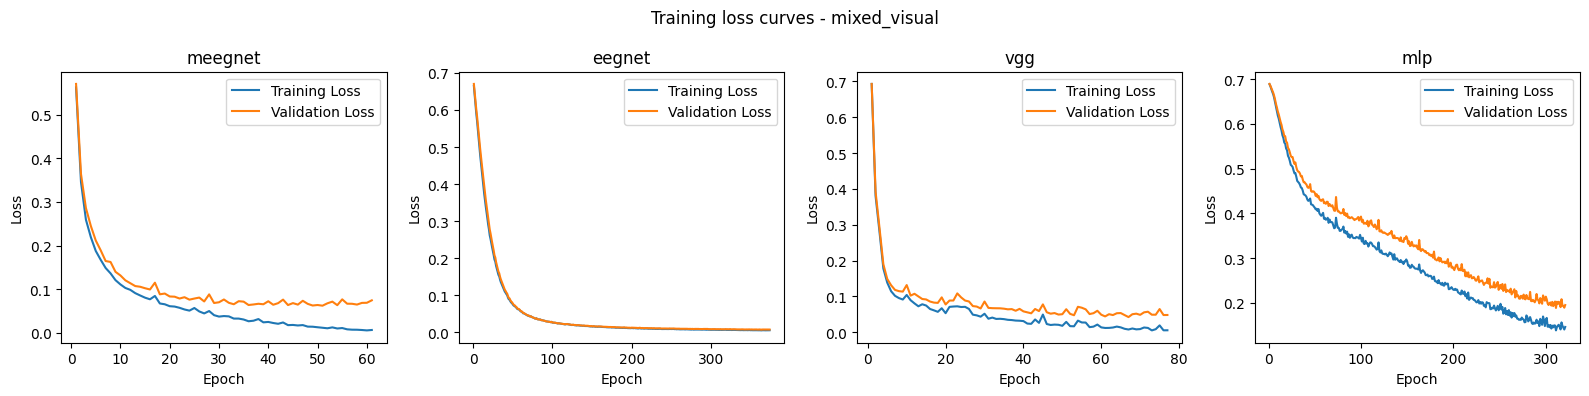

In [63]:
import matplotlib.pyplot as plt

# Number of models per task (net options)
n_models = len(net_options)

for classif in classif_tasks:
	fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4), squeeze=False)
	n_found = 0
	for j, net_option in enumerate(net_options):
		name = f'{classif}_{net_option}_{n_subjects}_{seed}_{n_channels}'
		mat_path = os.path.join(save_path, classif, name + '.mat')
		if not os.path.exists(mat_path):
			print(f'Warning: metrics file not found, skipping: {mat_path}')
			axes[0, j].set_axis_off()
			continue
		metrics = loadmat(mat_path)
		train_losses = np.array(metrics['train_losses']).squeeze()
		val_losses = np.array(metrics['validation_losses']).squeeze()
		epochs = np.arange(1, len(train_losses) + 1)
		n_found += 1
		ax = axes[0, j]
		ax.plot(epochs, train_losses, label='Training Loss')
		ax.plot(epochs, val_losses, label='Validation Loss')
		ax.set_title(net_option)
		ax.set_xlabel('Epoch')
		ax.set_ylabel('Loss')
		ax.legend()
	fig.suptitle(f'Training loss curves - {classif}')
	plt.tight_layout()
	plt.show()
	if n_found:
		fig.savefig(os.path.join(save_path, classif, f'loss_curves_{classif}.png'), dpi=300)